In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use('seaborn-v0_8')

In [2]:
BASE_DIR = "et_distributions"

index_path = os.path.join(BASE_DIR, "et_distributions_index.csv")
dist_dir = os.path.join(BASE_DIR, "distributions")

index_df = pd.read_csv(index_path)

print("Número de muestras:", len(index_df))
index_df.head()

Número de muestras: 3341


,sample_id,E_in,v_in,j_in,n_chunks,n_total,n_reactive,reactive_probability,dist_file,sum_P,min_Eout,max_Eout
0,1,0.5,0,0,1,100000,5537,0.05537,ETdist_id00001.dat,1.0,0.003349,0.590758
1,2,1.0,0,0,1,100000,4147,0.04147,ETdist_id00002.dat,1.0,0.049241,1.095167
2,3,1.5,0,0,1,100000,4428,0.04428,ETdist_id00003.dat,1.0,0.054417,1.590748
3,4,2.0,0,0,1,100000,5508,0.05508,ETdist_id00004.dat,1.0,0.071304,2.089825
4,5,2.5,0,0,1,100000,6779,0.06779,ETdist_id00005.dat,1.0,0.038036,2.590331


In [3]:
def load_distribution(row):
    filepath = os.path.join(dist_dir, row["dist_file"])
    data = np.loadtxt(filepath)
    E = data[:, 0]
    P = data[:, 1]
    return E, P

In [4]:
def plot_single(idx, save=True):
    row = index_df.iloc[idx]
    E, P = load_distribution(row)
    
    plt.figure(figsize=(6,4))
    plt.plot(E, P, lw=2)
    
    title = f"E={row['E_in']}, v={row['v_in']}, j={row['j_in']}"
    plt.title(title)
    plt.xlabel("E_out (eV)")
    plt.ylabel("P(E_out)")
    plt.grid(True)

    if save:
        filename = f"plot_E{row['E_in']}_v{row['v_in']}_j{row['j_in']}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight')

    plt.show()

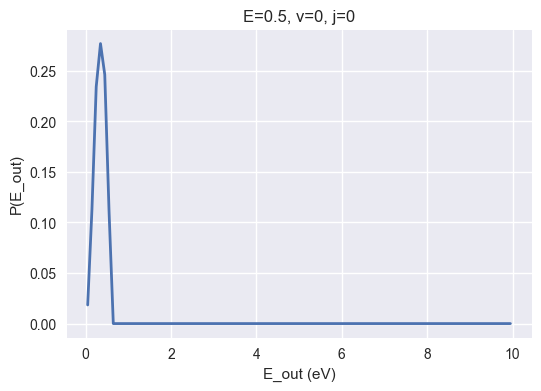

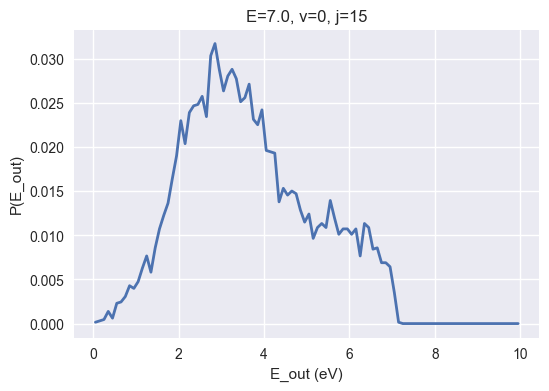

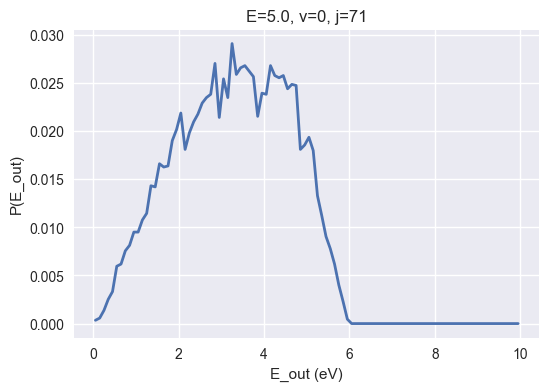

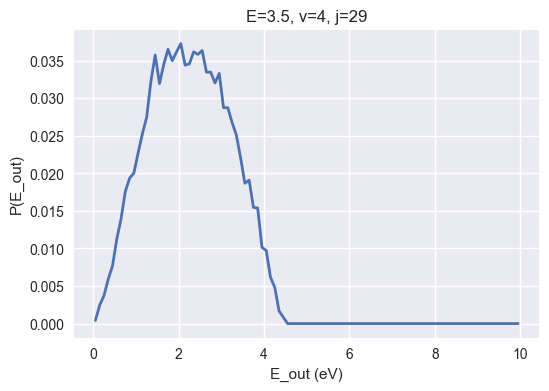

In [13]:
# ejemplos aleatorios
for i in [0, 50, 100,500]:
    plot_single(i)

In [15]:
def plot_multiple(indices, save=True):
    plt.figure(figsize=(7,5))
    
    for idx in indices:
        row = index_df.iloc[idx]
        E, P = load_distribution(row)
        plt.plot(E, P, label=f"E={row['E_in']}, v={row['v_in']}, j={row['j_in']}")
    
    plt.xlabel("E_out (eV)")
    plt.ylabel("P(E_out)")
    plt.legend()
    plt.grid(True)

    if save:
        filename = "plot_multiple.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight')

    plt.show()

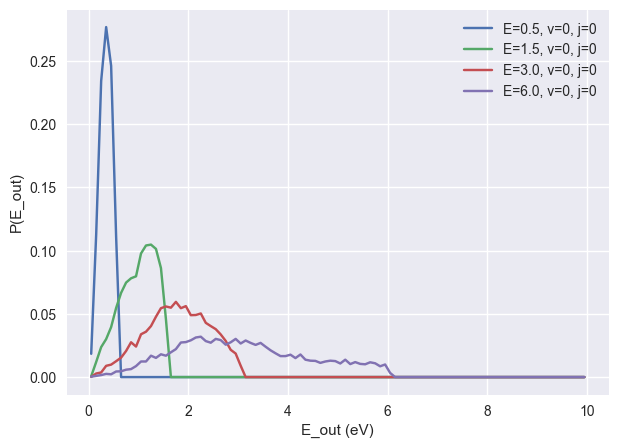

In [16]:
plot_multiple([0, 2, 5,10])

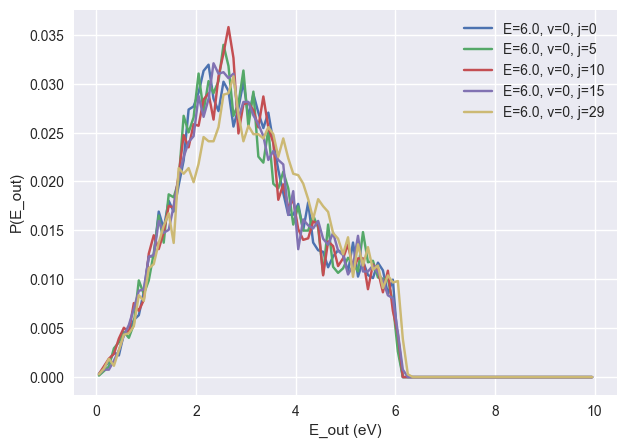

In [10]:
E_target = 6.0
v_target = 0

subset = index_df[
    (index_df["E_in"] == E_target) &
    (index_df["v_in"] == v_target)
]

subset = subset.sort_values("j_in")

indices = subset.index[:5]

plot_multiple(indices)

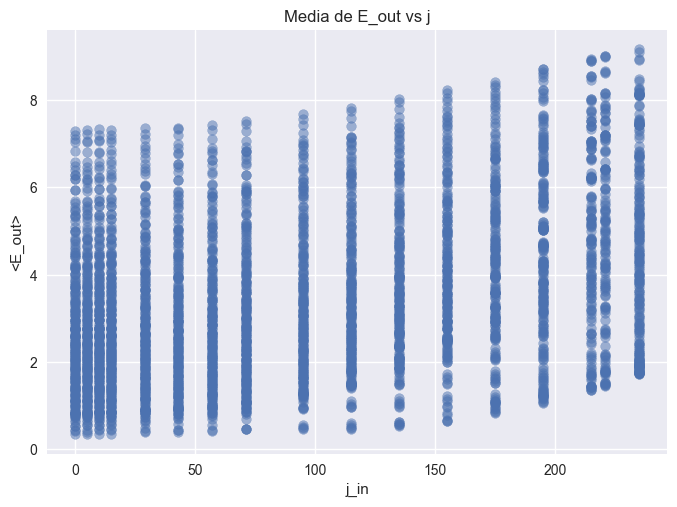

In [11]:
means = []

for _, row in index_df.iterrows():
    E, P = load_distribution(row)
    mean_E = np.sum(E * P)
    means.append(mean_E)

index_df["mean_Eout"] = means

plt.scatter(index_df["j_in"], index_df["mean_Eout"], alpha=0.5)
plt.xlabel("j_in")
plt.ylabel("<E_out>")
plt.title("Media de E_out vs j")
plt.grid(True)
plt.show()

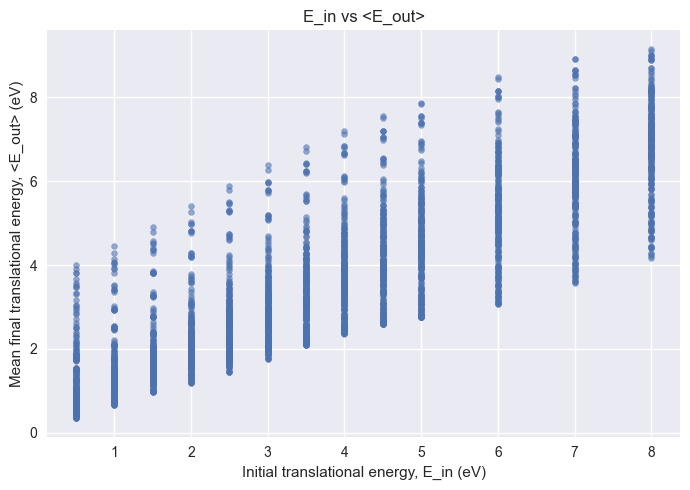

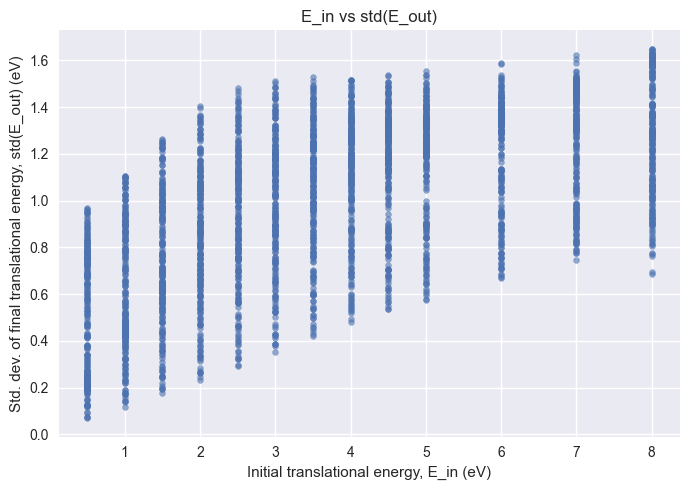

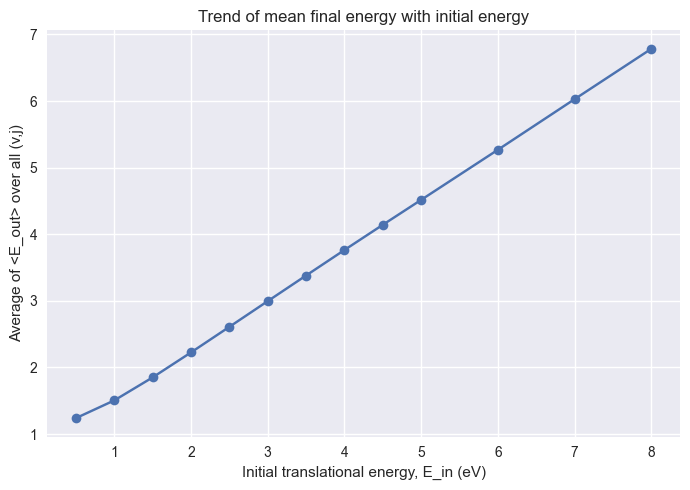

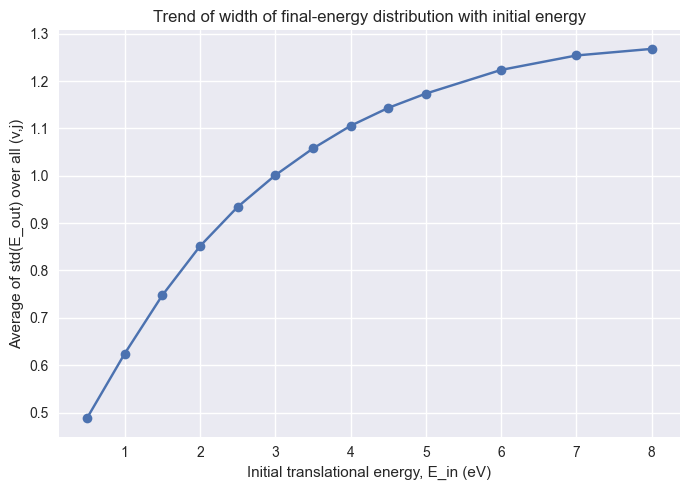

Plots saved in: et_distributions/figures


In [17]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "et_distributions"
INPUT_FILE = os.path.join(BASE_DIR, "et_moments_dataset.csv")
OUTDIR = os.path.join(BASE_DIR, "figures")

os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(INPUT_FILE)

# Opcional: quitar filas con NaN
df = df.dropna(subset=["E_in", "mean_Eout", "std_Eout"])

# -----------------------------------
# Plot 1: E_in vs mean_Eout
# -----------------------------------
plt.figure(figsize=(7,5))
plt.scatter(df["E_in"], df["mean_Eout"], alpha=0.6, s=18)

plt.xlabel("Initial translational energy, E_in (eV)")
plt.ylabel("Mean final translational energy, <E_out> (eV)")
plt.title("E_in vs <E_out>")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "E_in_vs_mean_Eout.png"), dpi=200)
plt.show()

# -----------------------------------
# Plot 2: E_in vs std_Eout
# -----------------------------------
plt.figure(figsize=(7,5))
plt.scatter(df["E_in"], df["std_Eout"], alpha=0.6, s=18)

plt.xlabel("Initial translational energy, E_in (eV)")
plt.ylabel("Std. dev. of final translational energy, std(E_out) (eV)")
plt.title("E_in vs std(E_out)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "E_in_vs_std_Eout.png"), dpi=200)
plt.show()

# -----------------------------------
# Plot 3: promedio por cada E_in
# -----------------------------------
grouped = df.groupby("E_in", as_index=False).agg({
    "mean_Eout": "mean",
    "std_Eout": "mean"
})

plt.figure(figsize=(7,5))
plt.plot(grouped["E_in"], grouped["mean_Eout"], marker="o")

plt.xlabel("Initial translational energy, E_in (eV)")
plt.ylabel("Average of <E_out> over all (v,j)")
plt.title("Trend of mean final energy with initial energy")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "trend_E_in_vs_mean_Eout.png"), dpi=200)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(grouped["E_in"], grouped["std_Eout"], marker="o")

plt.xlabel("Initial translational energy, E_in (eV)")
plt.ylabel("Average of std(E_out) over all (v,j)")
plt.title("Trend of width of final-energy distribution with initial energy")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "trend_E_in_vs_std_Eout.png"), dpi=200)
plt.show()

print("Plots saved in:", OUTDIR)